In [81]:
#----basic imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score, KFold

# ---- preprocessing (pipeline + columntransformer)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,FunctionTransformer

# ---- all models importing
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor         
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# -----metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,root_mean_squared_error

# -- boosting libraberies
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# fixed: was filter_warnings
import warnings
warnings.filterwarnings("ignore")

In [82]:
df = pd.read_csv("/Users/prem/MLPROJECTS/END_Projects/MLProjectsEND/notebook/data/student_performance_cleaned.csv")

In [83]:
df.head(10)

,Age,Gender,Semester,Department,Attendance,StudyHours,AssignmentScore,MidtermMarks,FinalExamMarks,SleepHours,...,Extracurricular,PreviousCGPA,ProjectsCompleted,Backlogs,FinalGPA,StudySleepRatio,InternetStudyRatio,AverageMarks,HasBacklog,HasProject
0,23,Male,6,DS,66.0,8.4,50.0,45,21,8.5,...,Yes,6.73,6,2.0,7.45,0.884211,0.319149,47.5,1,1
1,22,Male,1,DS,87.0,2.9,54.0,51,0,6.2,...,Yes,8.45,0,3.0,6.98,0.402778,0.820513,52.5,1,0
2,22,Female,1,ME,53.0,1.7,88.0,63,56,5.5,...,No,7.68,6,0.0,6.98,0.261538,2.518519,75.5,0,1
3,20,Male,4,ME,96.0,5.0,63.0,77,62,9.0,...,Yes,6.64,1,2.0,8.10,0.500000,0.716667,70.0,1,1
4,22,Male,1,CE,100.0,4.1,87.0,87,46,5.9,...,Yes,8.30,8,1.0,8.59,0.594203,0.666667,87.0,1,1
5,21,Female,7,CE,73.0,4.3,74.0,22,36,4.2,...,No,9.47,8,3.0,7.50,0.826923,1.226415,48.0,1,1
6,21,Male,4,IT,54.0,5.2,48.0,78,30,6.8,...,Yes,8.01,8,3.0,7.49,0.666667,0.129032,63.0,1,1
7,19,Male,2,ECE,78.0,9.4,59.0,69,53,5.1,...,No,8.09,3,3.0,8.35,1.540984,0.538462,64.0,1,1
8,21,Male,7,CE,86.0,3.1,37.0,44,83,8.4,...,NaN,6.09,0,2.0,7.52,0.329787,1.463415,40.5,1,0
9,24,Male,1,DS,63.0,7.4,99.0,28,46,6.5,...,No,8.65,4,0.0,8.79,0.986667,0.261905,63.5,0,1


In [84]:
(df.select_dtypes(include="number") < 0).sum()

Age                   0
Semester              0
Attendance            0
StudyHours            0
AssignmentScore       0
MidtermMarks          0
FinalExamMarks        0
SleepHours            0
InternetUsageHours    0
FamilyIncome          0
PreviousCGPA          0
ProjectsCompleted     0
Backlogs              0
FinalGPA              0
StudySleepRatio       0
InternetStudyRatio    0
AverageMarks          0
HasBacklog            0
HasProject            0
dtype: int64

In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7944 entries, 0 to 7943
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 7944 non-null   int64  
 1   Gender              7944 non-null   str    
 2   Semester            7944 non-null   int64  
 3   Department          7944 non-null   str    
 4   Attendance          7892 non-null   float64
 5   StudyHours          7944 non-null   float64
 6   AssignmentScore     7887 non-null   float64
 7   MidtermMarks        7944 non-null   int64  
 8   FinalExamMarks      7944 non-null   int64  
 9   SleepHours          7944 non-null   float64
 10  InternetUsageHours  7894 non-null   float64
 11  FamilyIncome        7887 non-null   float64
 12  ParentEducation     5971 non-null   str    
 13  Scholarship         7944 non-null   str    
 14  Hostel              7944 non-null   str    
 15  Extracurricular     7895 non-null   str    
 16  PreviousCGPA     

In [86]:
df.isnull().sum()

Age                      0
Gender                   0
Semester                 0
Department               0
Attendance              52
StudyHours               0
AssignmentScore         57
MidtermMarks             0
FinalExamMarks           0
SleepHours               0
InternetUsageHours      50
FamilyIncome            57
ParentEducation       1973
Scholarship              0
Hostel                   0
Extracurricular         49
PreviousCGPA             0
ProjectsCompleted        0
Backlogs                49
FinalGPA                 0
StudySleepRatio          0
InternetStudyRatio      50
AverageMarks            57
HasBacklog               0
HasProject               0
dtype: int64

In [87]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7939    False
7940    False
7941    False
7942    False
7943    False
Length: 7944, dtype: bool

In [88]:
from sklearn.model_selection import train_test_split


skewness_col = ["InternetStudyRatio"] 
non_skewness_col = [
    "Age",
    "Attendance",
    "StudyHours",
    "AssignmentScore",
    "MidtermMarks",
    "FinalExamMarks",
    "SleepHours",
    "InternetUsageHours",
    "FamilyIncome",
    "PreviousCGPA",
    "ProjectsCompleted",
    "Backlogs",
    "StudySleepRatio",
    "AverageMarks",
    "Semester"
]
binary_col = ["HasBacklog","HasProject"]
categorical_cols = ["Gender","Department","Extracurricular"]


features_col = skewness_col + non_skewness_col + binary_col + categorical_cols

X = df[features_col]
y = df["FinalGPA"]

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [90]:
skew_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", FunctionTransformer(np.log1p, validate=False)),
    ("scale", StandardScaler())])

plain_numeric_pipeline = Pipeline(steps=[(
    "imputer", SimpleImputer(strategy="mean")),
    ("scale", StandardScaler())])

binary_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))])
    # add ('encode', OneHotEncoder(drop='if_binary')) below ONLY if values are "Yes"/"No" text

nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))])


In [91]:
preprocessor = ColumnTransformer(transformers=[
    ("Skewed", skew_pipeline, skewness_col),
    ("Plain_Numeric", plain_numeric_pipeline, non_skewness_col),
    ("Binary", binary_pipeline, binary_col),
    ("Nominal", nominal_pipeline, categorical_cols),])

In [92]:
print(X_train.isnull().sum())

InternetStudyRatio    39
Age                    0
Attendance            45
StudyHours             0
AssignmentScore       45
MidtermMarks           0
FinalExamMarks         0
SleepHours             0
InternetUsageHours    39
FamilyIncome          45
PreviousCGPA           0
ProjectsCompleted      0
Backlogs              43
StudySleepRatio        0
AverageMarks          45
Semester               0
HasBacklog             0
HasProject             0
Gender                 0
Department             0
Extracurricular       39
dtype: int64


In [93]:
from sklearn import pipeline


models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "KNN": KNeighborsRegressor(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "ExtraTrees": ExtraTreesRegressor(random_state=42),
    "SVR": SVR(),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42),
    
}




results = []


for model_name, model in models.items():
    final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])
    
    final_pipeline.fit(X_train, y_train)
    pr_preds = final_pipeline.predict(X_test)
    pr_preds_train = final_pipeline.predict(X_train)

    pr_r2_testing = r2_score(y_test, pr_preds)
    pr_r2_training = r2_score(y_train, pr_preds_train)
    mae = mean_absolute_error(y_test, pr_preds)
    mse = mean_squared_error(y_test, pr_preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pr_preds)
            
            
    results.append({
        "Model": model_name,
        "Train R2": round(pr_r2_training,4),
        "Test R2": round(pr_r2_testing,4),
        "MAE": round(mae,4),
        "MSE": round(mse,4),
        "RMSE": round(rmse,4)
    })
    
    

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Test R2", ascending=False)
display(results_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000390 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1761
[LightGBM] [Info] Number of data points in the train set: 6355, number of used features: 30
[LightGBM] [Info] Start training from score 7.878725


,Model,Train R2,Test R2,MAE,MSE,RMSE
11,CatBoost,0.9075,0.7896,0.3918,0.2806,0.5297
0,LinearRegression,0.7690,0.7834,0.3898,0.2888,0.5374
1,Ridge,0.7690,0.7834,0.3898,0.2888,0.5374
8,GradientBoosting,0.8139,0.7816,0.3970,0.2911,0.5396
13,LightGBM,0.8836,0.7813,0.4000,0.2915,0.5399
10,SVR,0.8360,0.7744,0.4061,0.3008,0.5484
6,RandomForest,0.9620,0.7466,0.4276,0.3378,0.5812
9,ExtraTrees,1.0000,0.7450,0.4292,0.3400,0.5831
12,XGBoost,0.9703,0.7338,0.4412,0.3548,0.5957
4,KNN,0.7494,0.6494,0.5169,0.4674,0.6837


In [94]:
print(
    final_pipeline
    .named_steps["preprocessor"]
    .named_transformers_["Skewed"]
    .named_steps["imputer"]
    .statistics_
)

[0.78504673]


In [95]:
print(
    dict(zip(
        non_skewness_col,
        final_pipeline
        .named_steps["preprocessor"]
        .named_transformers_["Plain_Numeric"]
        .named_steps["imputer"]
        .statistics_
    ))
)

{'Age': np.float64(21.463571990558616), 'Attendance': np.float64(72.77480190174326), 'StudyHours': np.float64(4.961211644374508), 'AssignmentScore': np.float64(67.58177496038034), 'MidtermMarks': np.float64(60.69897718332022), 'FinalExamMarks': np.float64(59.17576711250983), 'SleepHours': np.float64(6.495531077891424), 'InternetUsageHours': np.float64(4.68948701709943), 'FamilyIncome': np.float64(159045.92567353408), 'PreviousCGPA': np.float64(7.448158929976397), 'ProjectsCompleted': np.float64(3.9350118017309206), 'Backlogs': np.float64(1.9727503168567808), 'StudySleepRatio': np.float64(0.6867422973604815), 'AverageMarks': np.float64(64.13740095087164), 'Semester': np.float64(4.475059008654602)}


In [96]:
print(
    dict(zip(
        categorical_cols,
        final_pipeline
        .named_steps["preprocessor"]
        .named_transformers_["Nominal"]
        .named_steps["imputer"]
        .statistics_
    ))
)

{'Gender': 'Female', 'Department': 'ME', 'Extracurricular': 'No'}


In [97]:
print(
    dict(zip(
        binary_col,
        final_pipeline
        .named_steps["preprocessor"]
        .named_transformers_["Binary"]
        .named_steps["imputer"]
        .statistics_
    ))
)

{'HasBacklog': np.float64(1.0), 'HasProject': np.float64(1.0)}


In [98]:
X_train_transformed = (
    final_pipeline
    .named_steps["preprocessor"]
    .transform(X_train)
)

In [99]:
import numpy as np

print(np.isnan(X_train_transformed).sum())

0


In [100]:
X.shape

(7944, 21)

In [101]:
y.shape

(7944,)

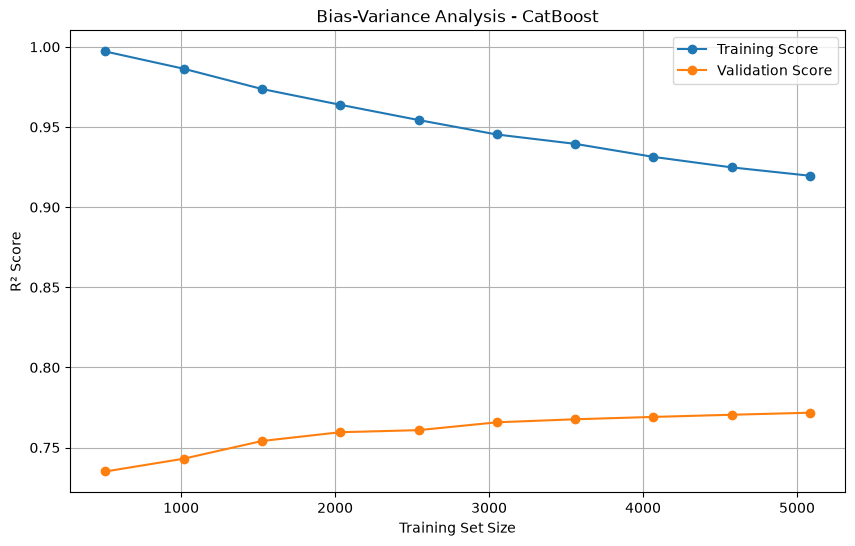

In [102]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import learning_curve
from catboost import CatBoostRegressor


# Best Model
catboost_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(
        verbose=0,
        random_state=42
    ))
])


# Learning Curve
train_sizes, train_scores, validation_scores = learning_curve(
    catboost_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)


# Mean scores
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)


# Graph
plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Score"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation Score"
)

plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Bias-Variance Analysis - CatBoost")
plt.legend()
plt.grid(True)

plt.show()

In [112]:
cv_scores = cross_val_score(final_pipeline, X, y, cv=5, scoring="r2")
print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1762
[LightGBM] [Info] Number of data points in the train set: 6355, number of used features: 30
[LightGBM] [Info] Start training from score 7.881440
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1761
[LightGBM] [Info] Number of data points in the train set: 6355, number of used features: 30
[LightGBM] [Info] Start training from score 7.871196
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000374 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

Tunning using GridSearch CV and  Randomized Search

In [103]:
catboost_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(verbose=0,random_state=42))
])

param_grid = {
    "model__iterations": [200, 300, 500],
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__l2_leaf_reg": [1, 3, 5]
}
grid_search = GridSearchCV(
    estimator=catboost_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters:
{'model__depth': 6, 'model__iterations': 500, 'model__l2_leaf_reg': 5, 'model__learning_rate': 0.03}


In [104]:
print("Best CV R²:", grid_search.best_score_)

Best CV R²: 0.7813838537264498


In [105]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Test R²:", test_r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

Test R²: 0.7984690841367448
MAE: 0.38242178712148117
MSE: 0.26867400623139287
RMSE: 0.5183377337522254


In [106]:
grid_search.best_score_

np.float64(0.7813838537264498)

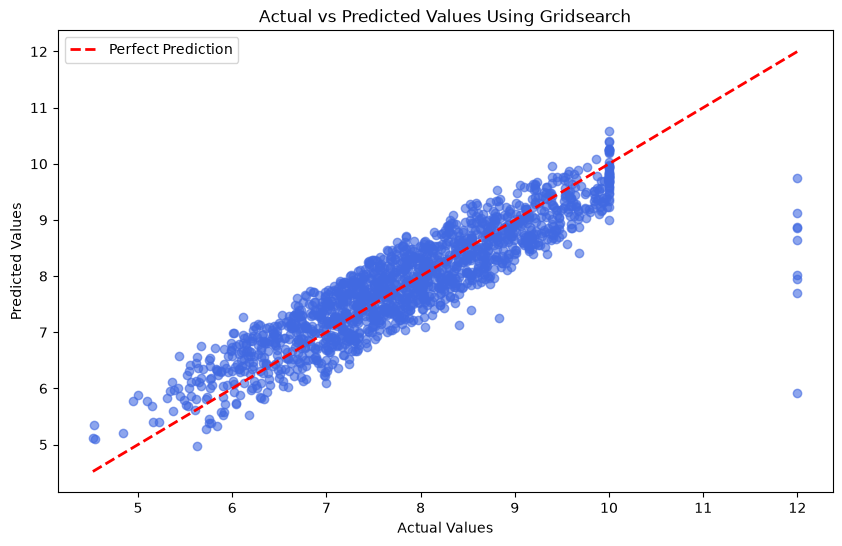

In [107]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue")
plt.plot([y_test.min(), y_test.max()], 
        [y_test.min(), y_test.max()], linewidth=2, linestyle='--', color="red", label="Perfect Prediction")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values Using Gridsearch")
plt.legend()
plt.show()

In [108]:
catboost_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(
        verbose=0,
        random_state=42
    ))
])

param_grid = {
    "model__iterations": [200, 300, 500, 700, 1000],
    "model__depth": [4, 5, 6, 7, 8, 10],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15],
    "model__l2_leaf_reg": [1, 3, 5, 7, 10],
}

random_search = RandomizedSearchCV(
    estimator=catboost_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)
print("Best Parameters:")
print(random_search.best_params_)



Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'model__learning_rate': 0.05, 'model__l2_leaf_reg': 10, 'model__iterations': 700, 'model__depth': 4}


In [109]:
print("Best CV R²:")
print(random_search.best_score_)

Best CV R²:
0.7810055724597268


In [110]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Test R²:", test_r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

Test R²: 0.7970029658185793
MAE: 0.3847700004196537
MSE: 0.27062858417028346
RMSE: 0.5202197460403473


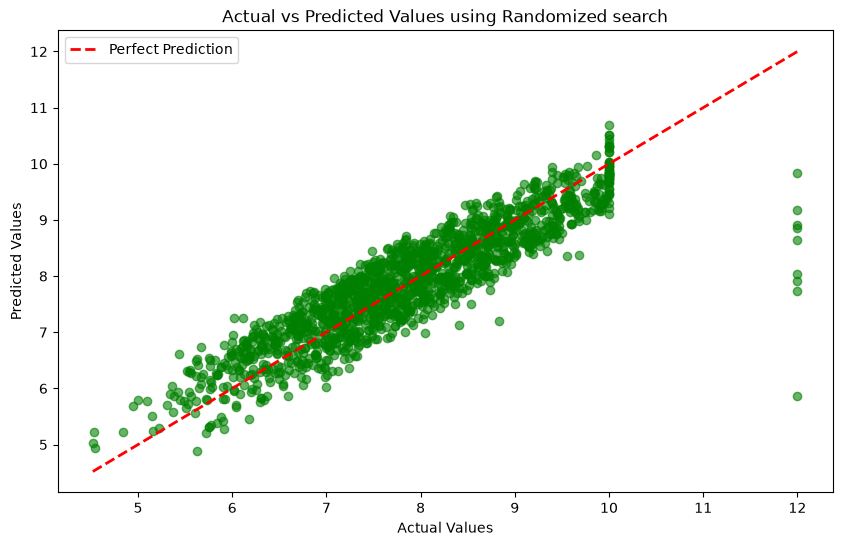

In [111]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="green")
plt.plot([y_test.min(), y_test.max()], 
        [y_test.min(), y_test.max()], linewidth=2, linestyle='--', color="red", label="Perfect Prediction")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values using Randomized search")
plt.legend()
plt.show()

In [114]:
df[df["FinalGPA"] == 12].describe()
df["FinalGPA"].value_counts().sort_index(ascending=False).head(10)

FinalGPA
12.00     47
10.00    248
9.99       6
9.98       4
9.97       5
9.96       3
9.95       6
9.94       8
9.93      13
9.92       3
Name: count, dtype: int64